In [1]:
#!/usr/bin/env python
"""
Benchmark: Cylindrical Waveguide Cavity - First 50 Modes
========================================================
Compares cavsim2d's eigenmode solver against closed-form analytical
solutions for the first 50 modes of a circular waveguide cavity.
"""

from __future__ import annotations
from scipy.optimize import linear_sum_assignment
import os
_REPO = os.path.dirname(r'C:\Users\Soske\Documents\git_projects\cavsim2d\benchmark')
from cavsim2d.cavity import *
import os
import matplotlib.pyplot as plt
import pandas as pd

from scipy.special import jn_zeros, jnp_zeros
import numpy as np

def compute_analytical_modes(
    R_mm: float,
    L_mm: float,
    max_modes: int = 100,
    max_m: int = 8,
    max_n: int = 25,
    max_p: int = 25,
):
    c = 299792458.0

    R = R_mm / 1000.0
    L = L_mm / 1000.0

    modes = []

    for m in range(max_m + 1):

        # ---------- TM ----------
        for n, root in enumerate(jn_zeros(m, max_n), start=1):
            for p in range(max_p):

                f = (c/(2*np.pi))*np.sqrt(
                    (root/R)**2 +
                    (p*np.pi/L)**2
                )/1e6

                mode = {
                    "family": "TM",
                    "m": m,
                    "n": n,
                    "p": p,
                    "frequency": f
                }

                modes.append(mode)

                # second angular solution
                if m > 0:
                    modes.append(mode.copy())

        # ---------- TE ----------

        p_start = 1 if m == 0 else 0

        # ---------- TE ----------
        for n, root in enumerate(jnp_zeros(m, max_n), start=1):

            kr = root / R

            # PEC cavity: p starts from 1
            for p in range(1, max_p+1):

                kz = p*np.pi/L

                f = c/(2*np.pi)*np.sqrt(
                    kr**2 + kz**2
                )/1e6

                modes.append({
                    "family": "TE",
                    "m": m,
                    "n": n,
                    "p": p,
                    "frequency": f,
                    "degenerate": 2 if m > 0 else 1
                })
    modes.sort(key=lambda mode: mode["frequency"])

    return modes[:max_modes]

def plot_multipole_convergence(
        df: pd.DataFrame,
        R_mm: float,
        L_mm: float,
        output_dir: str):
    """
    Generates convergence plots for a full 3D cavity spectrum.

    Modes are matched against the complete analytical spectrum
    containing all azimuthal mode numbers m.

    The solver mode_index is not used for tracking.
    Physical modes are assigned according to frequency matching.
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import linear_sum_assignment


    # ============================================================
    # Analytical spectrum (ALL m values)
    # ============================================================

    analytical_modes = compute_analytical_modes(
        R_mm,
        L_mm,
        max_modes=500
    )

    analytical_modes = sorted(
        analytical_modes,
        key=lambda x: x["frequency"]
    )

    analytical_freqs = np.array(
        [
            mode["frequency"]
            for mode in analytical_modes
        ]
    )

    analytical_m = np.array(
        [
            mode["m"]
            for mode in analytical_modes
        ]
    )


    # ============================================================
    # Match every numerical spectrum independently
    # ============================================================

    matched_results = []

    for (p, dofs), group in df.groupby(
        ["p", "No of DOFs"]
    ):

        group = group[
            group["freq [MHz]"] > 1.0
        ].copy()

        if group.empty:
            continue


        # sort numerical spectrum
        group = group.sort_values(
            "freq [MHz]"
        )


        sim_freqs = (
            group["freq [MHz]"]
            .to_numpy()
        )


        # only compare available modes
        n_modes = min(
            len(sim_freqs),
            len(analytical_freqs)
        )


        sim_freqs = sim_freqs[:n_modes]

        ana_freqs = analytical_freqs[:n_modes]


        # --------------------------------------------------------
        # Hungarian matching
        # --------------------------------------------------------

        cost = np.abs(
            sim_freqs[:, None]
            -
            ana_freqs[None, :]
        )


        row_ind, col_ind = linear_sum_assignment(
            cost
        )


        # --------------------------------------------------------
        # Create physically labelled spectrum
        # --------------------------------------------------------

        group = group.iloc[:n_modes].copy()


        physical_mode = np.full(
            n_modes,
            -1,
            dtype=int
        )

        matched_frequency = np.full(
            n_modes,
            np.nan
        )

        matched_m = np.full(
            n_modes,
            -1,
            dtype=int
        )


        for row, col in zip(
            row_ind,
            col_ind
        ):

            physical_mode[row] = row

            matched_frequency[row] = (
                analytical_freqs[col]
            )

            matched_m[row] = (
                analytical_m[col]
            )


        group["physical_mode"] = physical_mode

        group["analytical_freq"] = (
            matched_frequency
        )

        group["analytical_m"] = matched_m


        matched_results.append(group)



    if not matched_results:
        raise RuntimeError(
            "No numerical modes could be matched."
        )


    plot_df = pd.concat(
        matched_results,
        ignore_index=True
    )


    plot_df = plot_df[
        plot_df["physical_mode"] >= 0
    ]


    # ============================================================
    # Frequency error
    # ============================================================

    plot_df["rel_err_freq"] = (
        np.abs(
            plot_df["freq [MHz]"]
            -
            plot_df["analytical_freq"]
        )
        /
        plot_df["analytical_freq"]
    )


    # ============================================================
    # Plot settings
    # ============================================================

    p_colors = {
        1: '#17becf',
        2: '#1f77b4',
        3: '#ff7f0e',
        4: '#2ca02c',
        5: '#d62728',
        6: '#9467bd',
        7: '#8c564b',
        8: '#e377c2',
        9: '#7f7f7f',
        10:'#bcbd22'
    }


    mode_markers = [
        'o',
        's',
        '^',
        'v',
        'D',
        'P',
        '*',
        'X',
        '<',
        '>',
        'h',
        'H',
        'p',
        '8'
    ]


    unique_p = sorted(
        plot_df["p"].unique()
    )


    tracked_modes = sorted(
        plot_df["physical_mode"]
        .unique()
    )[:20]


    # ============================================================
    # Internal plotting function
    # ============================================================

    def make_plot(
            x_column,
            xlabel,
            filename):


        fig, ax = plt.subplots(
            figsize=(8, 6)
        )


        for p_idx, p in enumerate(unique_p):

            color = p_colors.get(
                p,
                plt.cm.tab10(
                    p_idx % 10
                )
            )


            for mode in tracked_modes:


                sub = plot_df[
                    (plot_df["p"] == p)
                    &
                    (plot_df["physical_mode"] == mode)
                ]


                if sub.empty:
                    continue


                sub = sub.sort_values(
                    x_column
                )


                m_value = int(
                    sub["analytical_m"]
                    .iloc[-1]
                )


                ax.plot(
                    sub[x_column],
                    sub["rel_err_freq"],

                    marker=
                    mode_markers[
                        mode %
                        len(mode_markers)
                    ],

                    linestyle="-",

                    color=color,

                    markeredgecolor="black",

                    alpha=0.8,

                    label=(
                        f"Mode {mode} "
                        f"(m={m_value}), "
                        f"p={p}"
                    )
                )


        ax.set_xscale("log")
        ax.set_yscale("log")


        ax.set_xlabel(
            xlabel,
            fontsize=11
        )


        ax.set_ylabel(
            r"Relative frequency deviation - $\sigma_\nu$",
            fontsize=11
        )


        ax.grid(
            True,
            which="both",
            linestyle=":",
            alpha=0.6
        )


        ax.legend(
            fontsize=7,
            ncol=2
        )


        fig.tight_layout()


        fig.savefig(
            os.path.join(
                output_dir,
                filename
            ),
            dpi=300
        )


        plt.close(fig)



    # ============================================================
    # Generate plots
    # ============================================================

    make_plot(
        "No of DOFs",
        r"Number of DOFs",
        "convergence_all_modes_vs_dofs.png"
    )


    make_plot(
        "time [s]",
        r"Computation time $t$ / s",
        "convergence_all_modes_vs_time.png"
    )


def plot_spectrum_comparison(df: pd.DataFrame, R_mm: float, L_mm: float, output_dir: str):
    """
    Plots the frequency spectrum as parallel vertical lines.
    Numerical modes are coloured according to their azimuthal mode number m.
    """

    # Finest mesh iteration
    fine_mesh_df = df[(df['p'] == df['p'].max()) &
                      (df['h_pass'] == df['h_pass'].max())].copy()

    fine_mesh_df = fine_mesh_df.sort_values('freq [MHz]')
    fine_mesh_df = fine_mesh_df[fine_mesh_df['freq [MHz]'] > 1.0]

    sim_freqs_ghz = fine_mesh_df['freq [MHz]'].values / 1000.0

    # Compute analytical modes
    analytical_modes = compute_analytical_modes(R_mm, L_mm, max_modes=100)
    analytical_ghz = np.array([mode["frequency"] for mode in analytical_modes]) / 1000.0


    # Colour map for azimuthal mode number
    m_cmap = plt.cm.tab10

    def m_colour(m):
        return m_cmap(m % 10)


    fig, ax = plt.subplots(figsize=(18, 4))


    # ------------------------------------------------------
    # Numerical spectrum coloured by m
    # ------------------------------------------------------
    for m, group in fine_mesh_df.groupby('m'):

        freqs = group['freq [MHz]'].values / 1000.0

        ax.vlines(freqs,
                  ymin=0.51,
                  ymax=0.9,
                  color=m_colour(m),
                  linewidth=1.0,
                  label=f"m={m}")

        ax.plot(freqs,
                np.full_like(freqs, 0.93),
                'v',
                color=m_colour(m),
                markersize=6)


    ax.text(min(sim_freqs_ghz)*0.98,
            0.7,
            'cavsim2d',
            fontsize=12,
            va='center',
            ha='right',
            weight='bold')


    # ------------------------------------------------------
    # Analytical spectrum
    # ------------------------------------------------------
    ax.vlines(analytical_ghz,
              ymin=0.1,
              ymax=0.49,
              color='black',
              linewidth=1.0)

    ax.plot(analytical_ghz,
            np.full_like(analytical_ghz, 0.07),
            '^',
            color='black',
            markersize=6)

    ax.text(min(sim_freqs_ghz)*0.98,
            0.3,
            'Analytic',
            fontsize=12,
            va='center',
            ha='right',
            weight='bold')


    # Formatting
    ax.set_xlabel(r"$f$ [GHz]", fontsize=12)
    ax.set_title("Eigenfrequency spectra: cavsim2d vs Analytic",
                 fontsize=14,
                 pad=15)

    ax.set_ylim(0, 1)
    ax.set_yticks([])

    ax.grid(True, axis='x', ls=":", alpha=0.4)

    all_freqs = np.concatenate([sim_freqs_ghz, analytical_ghz])
    # ax.set_xlim(min(all_freqs)*0.95, max(all_freqs)*1.05)
    ax.set_xlim(right=2.35)

    # Legend for multipoles
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(),
              by_label.keys(),
              loc='upper left',
              bbox_to_anchor=(1.01, 1),
              title="Azimuthal mode")

    fig.tight_layout()

    fig.savefig(os.path.join(output_dir, "spectrum_comparison.png"),
                dpi=300,
                bbox_inches='tight')

In [2]:
# Instantiate cavity
cavs = Study(r"C:\Users\Soske\Documents\git_projects\cavsim2d\benchmark")
cav = CircularWaveguide(R=230.0, L=200.0)
cavs.add_cavity([cav], ['circular_waveguide'])

# Configure solver for 50 modes 
eigenmode_config = {
    'processes': 1,
    'rerun': True,
    'boundary_conditions': 'mm',
    'mesh_config': {
        'h': 100,
        'p': 1
    },
    'nmodes': 20,
    'polarisation': ['monopole', 'dipole', 'quadrupole', 'sextupole', 'octupole', 'decapole', 'dodecapole', 'tetradecapole', 'hexadecapole']
}

# cavs.eigenmode_config = eigenmode_config
cav.study_mesh_convergence(eigenmode_config, h=100.0, h_passes=5, h_step=1.2, p=3, p_passes=3, p_step=1)

In [3]:
# from math import sqrt, pi
# xx = list([109.3230167908291, 356.06315746740177, 576.0166780510908, 822.7571634682466, 1096.2834816288228, 1415.6348458281839, 1562.9774885651743, 1662.376410889258])
# c0 = 299792458
# [c0 * sqrt(abs(x)) / (2 * pi) * 1e-6 for x in xx]

In [9]:
print(cavs[0].convergence_df_data)

      m  polarisation  Normalization Length [mm]  N Cells  \
0     0      monopole                      200.0        1   
1     0      monopole                      200.0        1   
2     0      monopole                      200.0        1   
3     0      monopole                      200.0        1   
4     0      monopole                      200.0        1   
...  ..           ...                        ...      ...   
2957  8  hexadecapole                        2.0        1   
2958  8  hexadecapole                        2.0        1   
2959  8  hexadecapole                        2.0        1   
2960  8  hexadecapole                        2.0        1   
2961  8  hexadecapole                        2.0        1   

                freq [MHz]                    Q []          Vacc [MV]  \
0      498.878838892280839   36639.565396345737099  0.000004381786285   
1      901.192949399108898   28515.993456155054446  0.000002223883800   
2     1145.074550874727038   51933.0144662888851

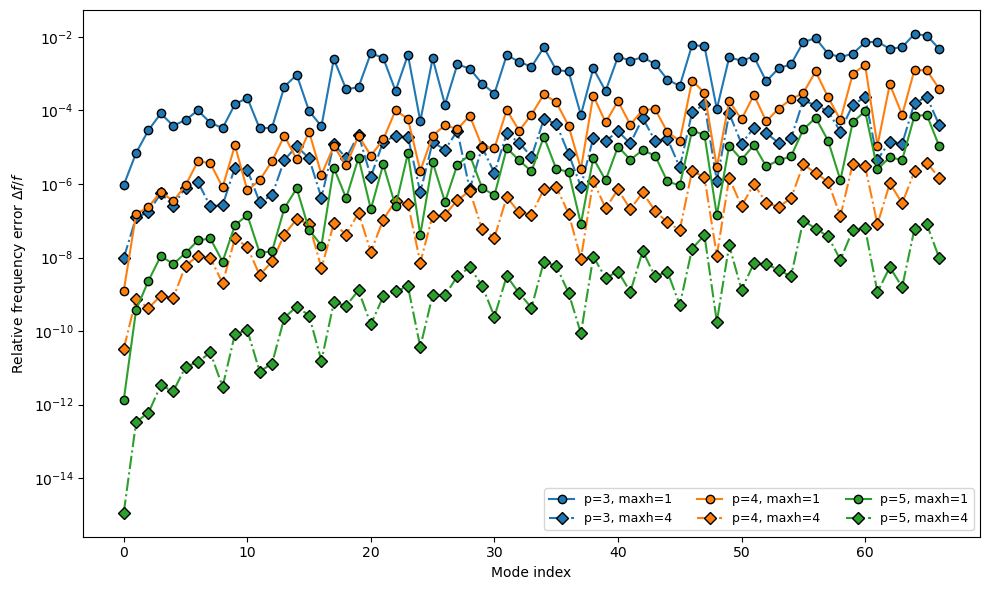

In [10]:
# print(cavs[0].convergence_df_data['freq [MHz]'])
pd.set_option("display.precision", 15)
pd.options.display.precision

analytical_freqs = np.sort(list(set([mode["frequency"] for mode in compute_analytical_modes(R_mm=230.0, L_mm=200.0, max_modes=100)])))

df = cavs[0].convergence_df_data

p_colors = {3:"tab:blue", 4:"tab:orange", 5:"tab:green"}
hp_markers = {1:"o", 2:"s", 3:"^", 4:"D"}
hp_styles = {1:"-", 2:"--", 3:":", 4:"-."}

plt.figure(figsize=(10,6))

for p in [3,4,5]:
    for hp in [1,4]:
        num_freq = np.sort(df.loc[(df["p"] == p) & (df["h_pass"] == hp), "freq [MHz]"].to_numpy())[:len(analytical_freqs)]
        plt.plot(np.abs(analytical_freqs-num_freq)/analytical_freqs, color=p_colors[p], linestyle=hp_styles[hp], marker=hp_markers[hp], label=f"p={p}, maxh={hp}", mec="k")

plt.yscale("log")
plt.xlabel("Mode index")
plt.ylabel(r"Relative frequency error $\Delta f/f$")
plt.legend(ncols=3, fontsize=9)
plt.tight_layout()
plt.show()

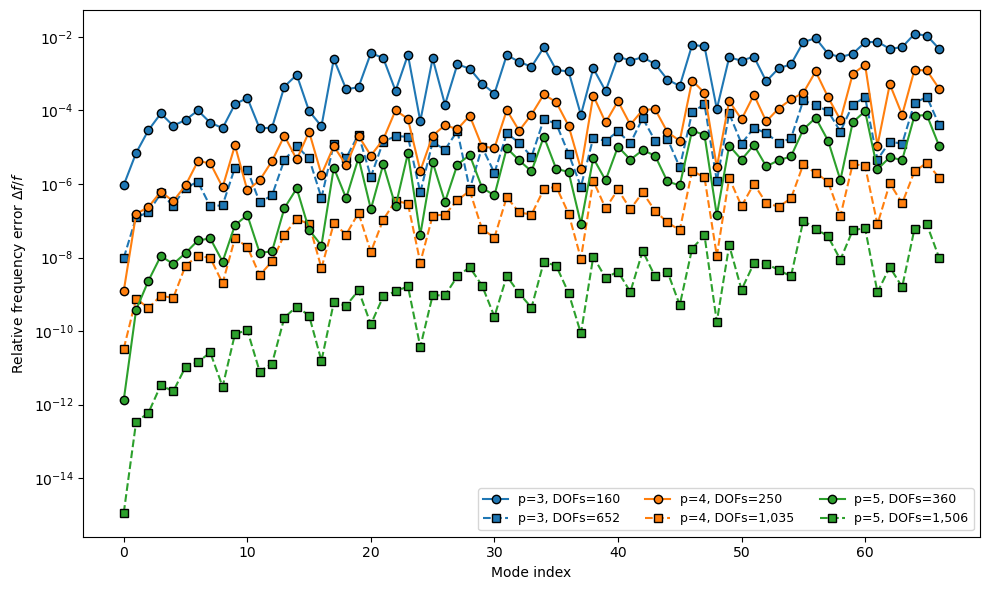

In [14]:
analytical_freqs = np.sort(
    list(
        set(
            [
                mode["frequency"]
                for mode in compute_analytical_modes(
                    R_mm=230.0, L_mm=200.0, max_modes=100
                )
            ]
        )
    )
)

df = cavs[0].convergence_df_data

p_colors = {3: "tab:blue", 4: "tab:orange", 5: "tab:green"}
hp_markers = {1: "o", 4: "s"}  # Updated keys to match your actual hp values
hp_styles = {1: "-", 4: "--"}  # Updated keys to match your actual hp values

plt.figure(figsize=(10, 6))

for p in [3, 4, 5]:
    for hp in [1, 4]:
        # Filter the dataframe for the current combination
        df_filtered = df.loc[(df["p"] == p) & (df["h_pass"] == hp)]

        # Skip if the combination doesn't exist in your dataframe
        if df_filtered.empty:
            continue

        # Extract the DOFs associated with this exact filter
        dofs = int(df_filtered["No of DOFs"].iloc[0])

        num_freq = np.sort(df_filtered["freq [MHz]"].to_numpy())[
            : len(analytical_freqs)
        ]

        # Use the dofs variable dynamically inside the label string
        plt.plot(
            np.abs(analytical_freqs - num_freq) / analytical_freqs,
            color=p_colors[p],
            linestyle=hp_styles[hp],
            marker=hp_markers[hp],
            label=f"p={p}, DOFs={dofs:,}",
            mec="k",
        )

plt.yscale("log")
plt.xlabel("Mode index")
plt.ylabel(r"Relative frequency error $\Delta f/f$")
plt.legend(ncols=3, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# analytical_freqs = compute_analytical_modes(R_mm=230.0, L_mm=200.0, max_modes=50)
# print(analytical_freqs)

In [ ]:
results_df = cav.convergence_df_data

# 3. Call the Plotting Functions
print("Generating publication-quality plots...")
output_dir = r'C:\Users\Soske\Documents\git_projects\cavsim2d\benchmark\cylindrical_waveguide'
# Plot 1 & 2: Convergence log-log plots (Relative error vs Elements & vs Time)
plot_multipole_convergence(
    df=results_df,
    R_mm=230.0,
    L_mm=200,
    output_dir=output_dir
)

# Plot 3: The 50-mode Frequency vs. Modenumber step-scatter plot
plot_spectrum_comparison(
    df=results_df,
    R_mm=230.0,
    L_mm=200,
    output_dir=output_dir
)

In [ ]:
cavs[0].plot_mesh()

In [20]:
print(cavs[0].convergence_df_data['frequency'][:67].tolist())

KeyError: 'frequency'